# SARIMA Car Registrations Forecast

**Target Variable:** `Car_Registrations` (univariate)  
**Data Range:** 2000-01 -> 2026-04 (316 months)   
**Train/Test Split:** Last 64 months as test  

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import zscore
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm

pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

%matplotlib inline
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Dataset & Remove Outliers

In [8]:
df = pd.read_csv('../../scraping/car_registrations.csv')
df.columns = ['Date', 'Car_Registrations']
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset shape before outlier handling: {df.shape}')
print(f'Date range: {df["Date"].min().date()} → {df["Date"].max().date()}')

# Outlier handling: replace extreme values (|z|>3) with rolling median
z_scores = np.abs(zscore(df['Car_Registrations']))
rolling_median = df['Car_Registrations'].rolling(window=12, center=True, min_periods=1).median()
df['Car_Registrations'] = np.where(z_scores > 3, rolling_median, df['Car_Registrations'])

n_outliers = (z_scores > 3).sum()
print(f'Outliers replaced (|z|>3): {n_outliers}')
print(f'\nStatistics after handling:')
print(df['Car_Registrations'].describe())

Dataset shape before outlier handling: (316, 2)
Date range: 2000-01-01 → 2026-04-01
Outliers replaced (|z|>3): 3

Statistics after handling:
count     316.00
mean    49802.50
std     13150.97
min      8400.00
25%     41117.00
50%     48603.50
75%     58017.50
max     84429.00
Name: Car_Registrations, dtype: float64


## 3. Convert to Time Series with Monthly Frequency

In [9]:
series = df.set_index('Date')['Car_Registrations'].astype(float)
series.index.freq = 'MS'  # Monthly Start frequency

print(f'Series length: {len(series)}')
print(f'Frequency: {series.index.freq}')
print(series.head(3))
print('...')
print(series.tail(3))

Series length: 316
Frequency: <MonthBegin>
Date
2000-01-01   26064.00
2000-02-01   23929.00
2000-03-01   32057.00
Freq: MS, Name: Car_Registrations, dtype: float64
...
Date
2026-02-01   56690.00
2026-03-01   67846.00
2026-04-01   77869.00
Freq: MS, Name: Car_Registrations, dtype: float64


## 4. Visualize the Time Series

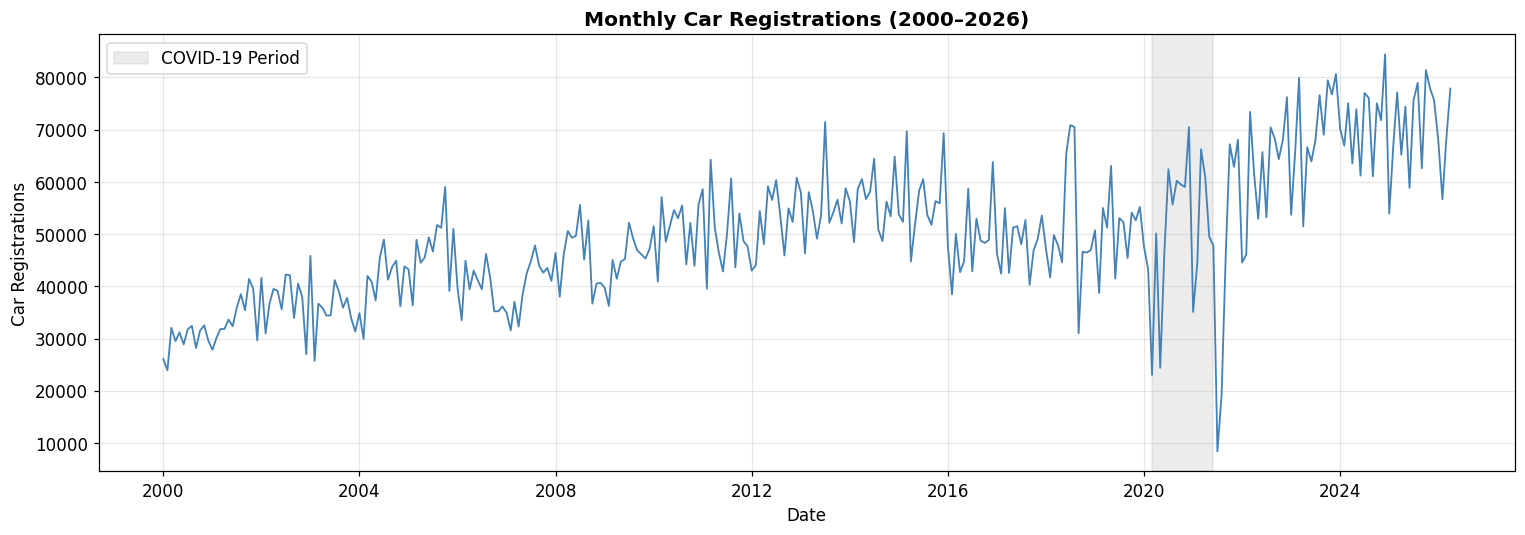

Figure saved: 01_time_series_overview.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(series.index, series.values, color='steelblue', linewidth=1.2)
ax.set_title('Monthly Car Registrations (2000–2026)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Car Registrations')
ax.grid(alpha=0.3)

# Shade COVID period
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.15, color='gray', label='COVID-19 Period')
ax.legend()
plt.tight_layout()
plt.savefig('01_time_series_overview.png', bbox_inches='tight')
plt.show()
print('Figure saved: 01_time_series_overview.png')

## 5. Stationarity Tests


In [12]:
def stationarity_tests(s, name):
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    
    adf_result = adfuller(s.dropna(), autolag='AIC')
    adf_stat, adf_p = adf_result[0], adf_result[1]
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  ADF p-value   : {adf_p:.4f}")
    print(f"  ADF Decision  : {'STATIONARY' if adf_p < 0.05 else 'NON-STATIONARY'}")
    
    kpss_result = kpss(s.dropna(), regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    print(f"  KPSS Statistic: {kpss_stat:.4f}")
    print(f"  KPSS p-value  : {kpss_p:.4f}")
    print(f"  KPSS Decision : {'STATIONARY' if kpss_p > 0.05 else 'NON-STATIONARY'}")
    print()

stationarity_tests(series, 'Car Registrations (Original)')
stationarity_tests(series.diff().dropna(), 'Car Registrations (1st Difference, d=1)')
stationarity_tests(series.diff(12).dropna(), 'Car Registrations (Seasonal Diff, D=1, s=12)')
stationarity_tests(series.diff().diff(12).dropna(), 'Car Registrations (d=1, D=1, s=12)')

  Car Registrations (Original)
  ADF Statistic : -0.8776
  ADF p-value   : 0.7953
  ADF Decision  : NON-STATIONARY
  KPSS Statistic: 2.1738
  KPSS p-value  : 0.0100
  KPSS Decision : NON-STATIONARY

  Car Registrations (1st Difference, d=1)
  ADF Statistic : -7.6017
  ADF p-value   : 0.0000
  ADF Decision  : STATIONARY
  KPSS Statistic: 0.0399
  KPSS p-value  : 0.1000
  KPSS Decision : STATIONARY

  Car Registrations (Seasonal Diff, D=1, s=12)
  ADF Statistic : -3.7917
  ADF p-value   : 0.0030
  ADF Decision  : STATIONARY
  KPSS Statistic: 0.0831
  KPSS p-value  : 0.1000
  KPSS Decision : STATIONARY

  Car Registrations (d=1, D=1, s=12)
  ADF Statistic : -7.8848
  ADF p-value   : 0.0000
  ADF Decision  : STATIONARY
  KPSS Statistic: 0.0364
  KPSS p-value  : 0.1000
  KPSS Decision : STATIONARY



C:\Users\USER\AppData\Local\Temp\ipykernel_17480\134412953.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(s.dropna(), regression='c', nlags='auto')
C:\Users\USER\AppData\Local\Temp\ipykernel_17480\134412953.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(s.dropna(), regression='c', nlags='auto')
C:\Users\USER\AppData\Local\Temp\ipykernel_17480\134412953.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(s.dropna(), regression='c', nlags='auto')
C:\Users\USER\AppData\Local\Temp\ipykernel_17480\134412953.py:12: InterpolationWarning: The test statistic is ou

## 6. ACF & PACF Analysis

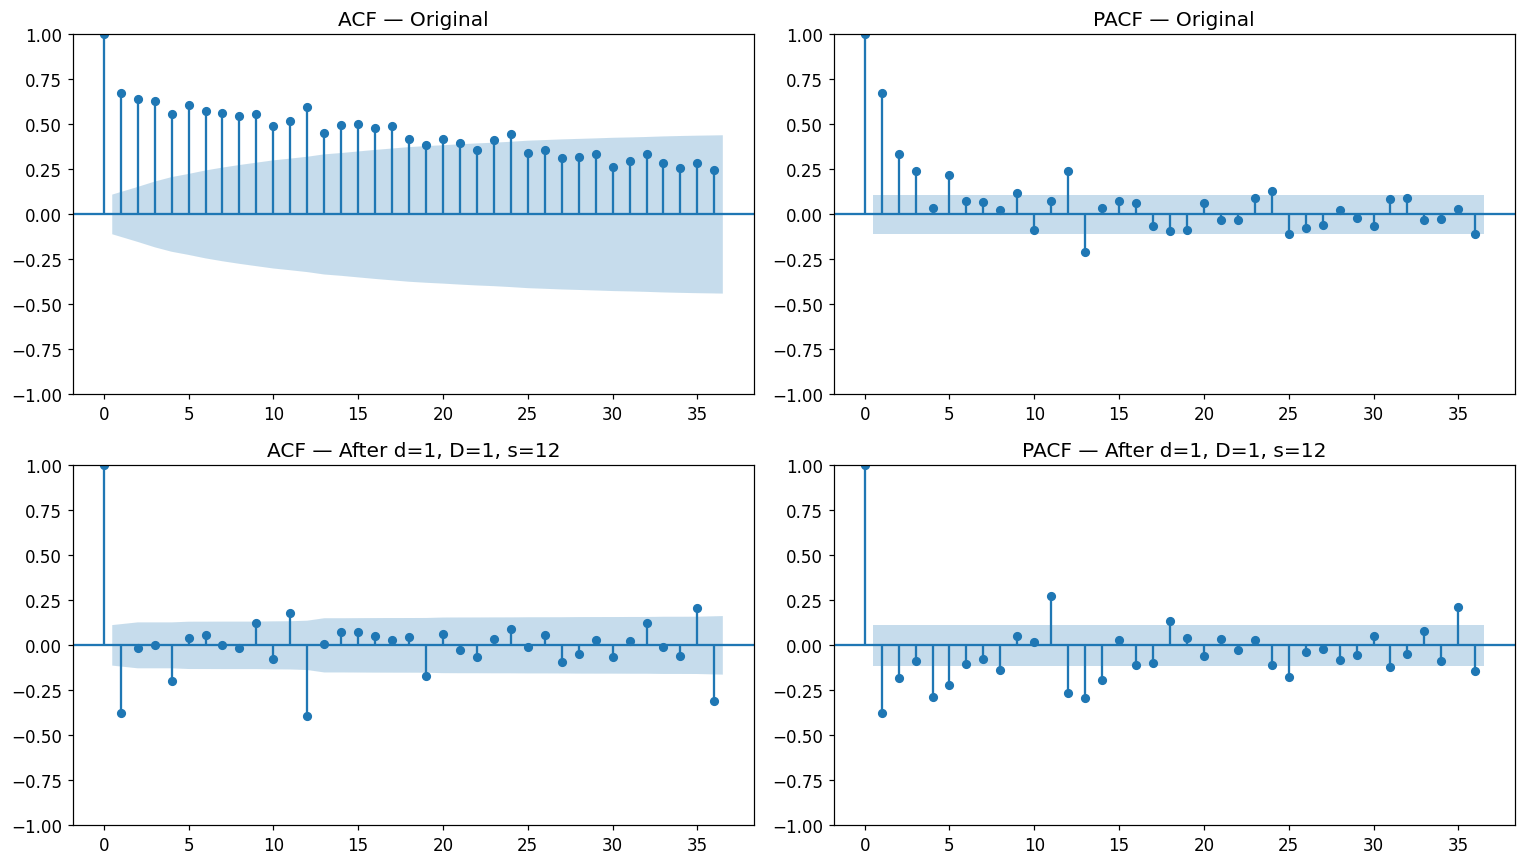

Figure saved: 02_acf_pacf.png

Interpretation:
  - Spikes at lag 12, 24, 36 in original ACF → strong seasonality (s=12)
  - Significant lag k in PACF (after diff) → AR order p = k
  - Significant lag k in ACF  (after diff) → MA order q = k


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(series, lags=36, ax=axes[0, 0], title='ACF — Original')
plot_pacf(series, lags=36, ax=axes[0, 1], title='PACF — Original', method='ywm')

diff_series = series.diff().diff(12).dropna()
plot_acf(diff_series, lags=36, ax=axes[1, 0], title='ACF — After d=1, D=1, s=12')
plot_pacf(diff_series, lags=36, ax=axes[1, 1], title='PACF — After d=1, D=1, s=12', method='ywm')

plt.tight_layout()
plt.savefig('02_acf_pacf.png', bbox_inches='tight')
plt.show()
print('Figure saved: 02_acf_pacf.png')
print()
print('Interpretation:')
print('  - Spikes at lag 12, 24, 36 in original ACF → strong seasonality (s=12)')
print('  - Significant lag k in PACF (after diff) → AR order p = k')
print('  - Significant lag k in ACF  (after diff) → MA order q = k')

## 7. Train/Test Split (Last 64 Months as Test)

Train: 2000-01-01 → 2020-12-01  (252 months)
Test : 2021-01-01  → 2026-04-01   (64 months)


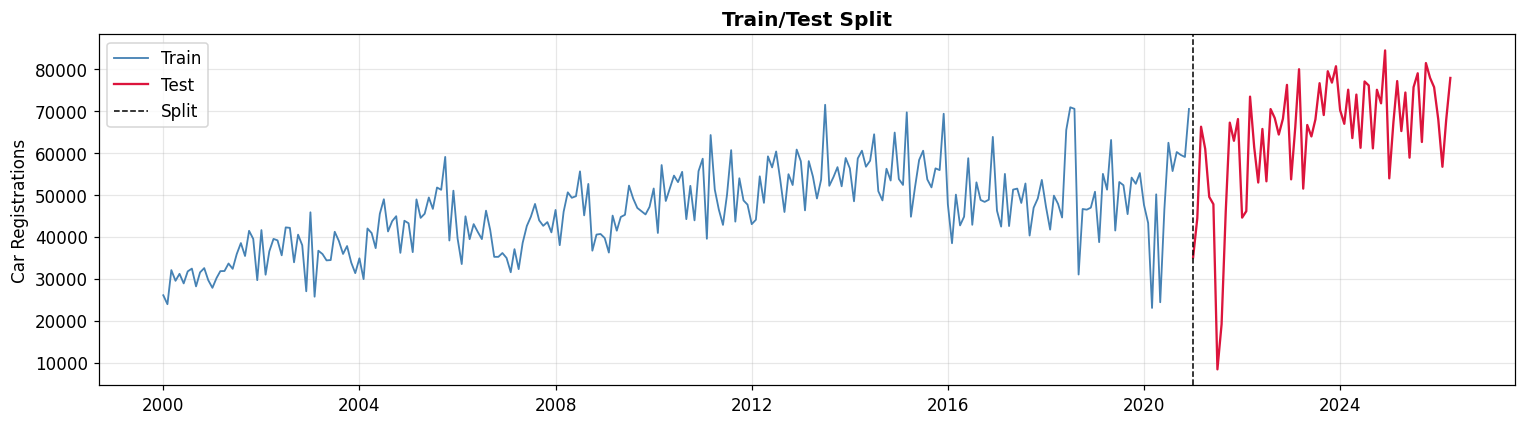

In [14]:
test_size = 64
train = series.iloc[:-test_size]
test  = series.iloc[-test_size:]

print(f'Train: {train.index[0].date()} → {train.index[-1].date()}  ({len(train)} months)')
print(f'Test : {test.index[0].date()}  → {test.index[-1].date()}   ({len(test)} months)')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, train.values, label='Train', color='steelblue', linewidth=1.2)
ax.plot(test.index,  test.values,  label='Test',  color='crimson',   linewidth=1.5)
ax.axvline(x=test.index[0], color='black', linestyle='--', linewidth=1, label='Split')
ax.set_title('Train/Test Split', fontweight='bold')
ax.set_ylabel('Car Registrations')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('03_train_test_split.png', bbox_inches='tight')
plt.show()

## 8. Auto-ARIMA - Automatic Order Selection

In [16]:
print('Running auto_arima stepwise search\n')

auto_model = pm.auto_arima(
    train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,                 # auto-determine non-seasonal differencing
    seasonal=True,
    m=12,                   # 12-month seasonality
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,                 # auto-determine seasonal differencing
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

order = auto_model.order
seasonal_order = auto_model.seasonal_order

print()
print(f'Best SARIMA order            : {order}')
print(f'Best seasonal order (s=12)   : {seasonal_order}')
print(f'AIC: {auto_model.aic():.2f}')
print(f'BIC: {auto_model.bic():.2f}')

Running auto_arima stepwise search

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=5283.868, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=5175.261, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=5158.759, Time=0.26 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=5281.968, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=5171.128, Time=0.06 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=5155.715, Time=0.13 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=5156.211, Time=0.08 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=5149.857, Time=0.32 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=5149.398, Time=0.21 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=5248.873, Time=0.15 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=5148.270, Time=0.24 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=5156.771, Time=0.12 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=5150.092, Time=0.53 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=5140.09

## 9. Fit Final SARIMA Model

In [17]:
sarima_model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                  Car_Registrations   No. Observations:                  252
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood               -2424.626
Date:                            Tue, 09 Jun 2026   AIC                           4857.251
Time:                                    15:39:25   BIC                           4871.124
Sample:                                01-01-2000   HQIC                          4862.843
                                     - 12-01-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7471      0.040    -18.825      0.000      -0.825      -0.669
ar.S.L12       0.8826      0.070   

## 10. Forecast on Test Set

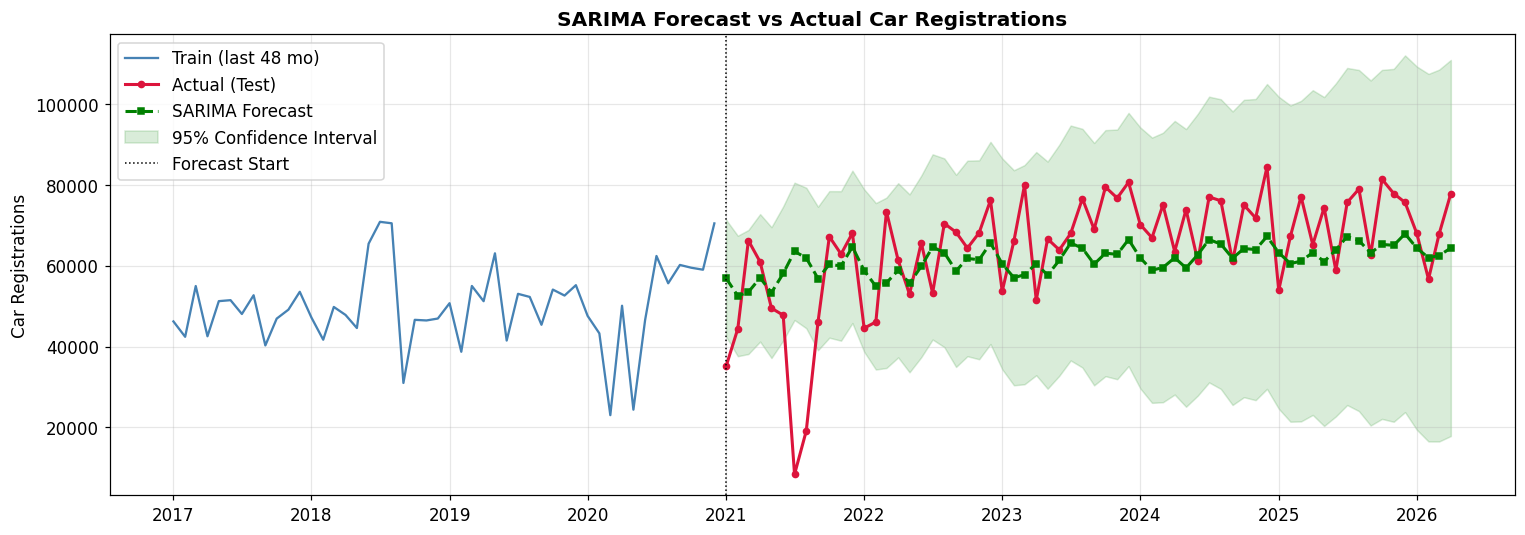

Figure saved: 04_actual_vs_predicted.png


In [18]:
forecast_obj = sarima_fit.get_forecast(steps=test_size)
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)  # 95% CI

fig, ax = plt.subplots(figsize=(14, 5))
# Plot only recent training history to keep visualisation clear
recent_train = train.iloc[-48:]
ax.plot(recent_train.index, recent_train.values, label='Train (last 48 mo)', color='steelblue', linewidth=1.5)
ax.plot(test.index, test.values, label='Actual (Test)', color='crimson', linewidth=2, marker='o', markersize=4)
ax.plot(test.index, forecast_mean.values, label='SARIMA Forecast', color='green', linewidth=2, linestyle='--', marker='s', markersize=4)
ax.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                color='green', alpha=0.15, label='95% Confidence Interval')
ax.axvline(x=test.index[0], color='black', linestyle=':', linewidth=1, label='Forecast Start')
ax.set_title('SARIMA Forecast vs Actual Car Registrations', fontweight='bold')
ax.set_ylabel('Car Registrations')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('04_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print('Figure saved: 04_actual_vs_predicted.png')

## 11. Evaluation Metrics

In [19]:
def evaluate(y_true, y_pred, label='Test'):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  SARIMA Evaluation — {label}")
    print(f"{'='*50}")
    print(f"  MSE  : {mse:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  R²   : {r2:.4f}")
    print(f"{'='*50}")
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}

test_metrics  = evaluate(test.values, forecast_mean.values, label='Test (last 64 months)')

# Compact display
results_metrics = pd.DataFrame([test_metrics], index=['SARIMA'])[['mse', 'rmse', 'r2']]
print('\nFor direct comparison with baseline/LSTM notebooks:')
print(results_metrics)


  SARIMA Evaluation — Test (last 64 months)
  MSE  : 179,794,049.65
  RMSE : 13,408.73
  MAE  : 10,227.54
  MAPE : 27.17%
  R²   : 0.0943

For direct comparison with baseline/LSTM notebooks:
                mse     rmse   r2
SARIMA 179794049.65 13408.73 0.09


## 12. Residual Diagnostics

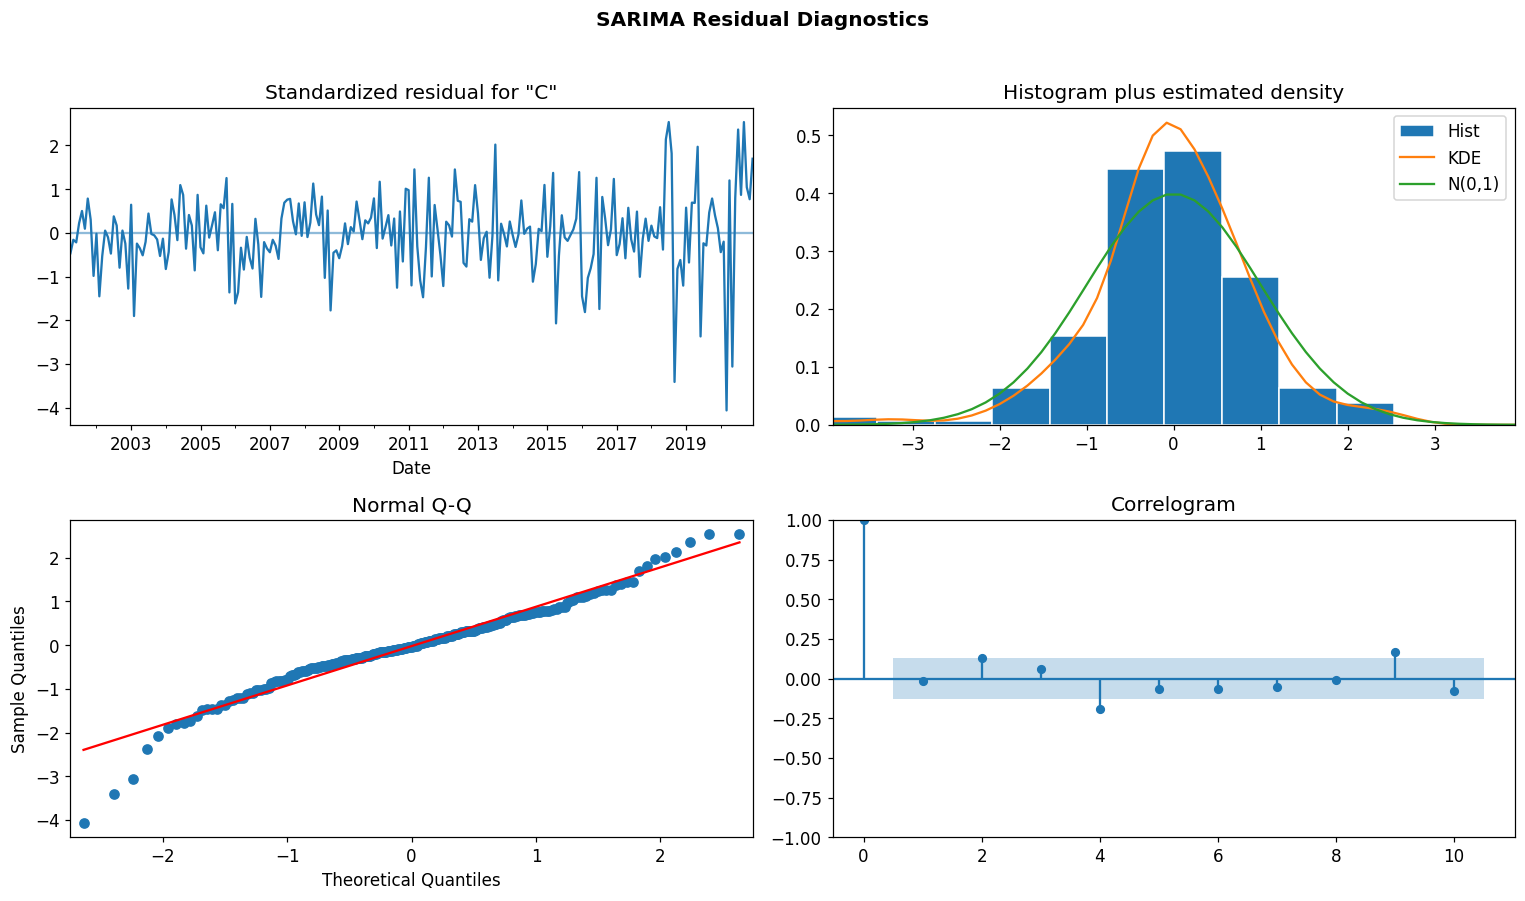

Figure saved: 05_residual_diagnostics.png

Ljung-Box Test for Residual Autocorrelation:
(H0: residuals are white noise — p > 0.05 means good)
    lb_stat  lb_pvalue
6     14.86       0.02
12    23.11       0.03
24    43.88       0.01
36    62.95       0.00

Residuals look like white noise: Some autocorrelation remains


In [20]:
fig = sarima_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA Residual Diagnostics', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('05_residual_diagnostics.png', bbox_inches='tight')
plt.show()
print('Figure saved: 05_residual_diagnostics.png')

# Ljung-Box test
residuals = sarima_fit.resid
lb_test = acorr_ljungbox(residuals, lags=[6, 12, 24, 36], return_df=True)
print()
print('Ljung-Box Test for Residual Autocorrelation:')
print('(H0: residuals are white noise — p > 0.05 means good)')
print(lb_test.to_string())
print()
all_pass = (lb_test['lb_pvalue'] > 0.05).all()
print(f'Residuals look like white noise: {"YES" if all_pass else "Some autocorrelation remains"}')

## 13. Monthly Forecast Table

In [21]:
results_df = pd.DataFrame({
    'Date': test.index,
    'Actual': test.values.astype(int),
    'Predicted': forecast_mean.values.round(0).astype(int),
    'CI_Lower': conf_int.iloc[:, 0].values.round(0).astype(int),
    'CI_Upper': conf_int.iloc[:, 1].values.round(0).astype(int),
})
results_df['Abs_Error'] = np.abs(results_df['Actual'] - results_df['Predicted'])
results_df['Pct_Error'] = (results_df['Abs_Error'] / results_df['Actual'] * 100).round(2)

print('First 12 months of test set forecast:')
print(results_df.head(12).to_string(index=False))
print('...')
print('Last 12 months of test set forecast:')
print(results_df.tail(12).to_string(index=False))

results_df.to_csv('sarima_forecast_results.csv', index=False)
print('\nFull results saved: sarima_forecast_results.csv')

First 12 months of test set forecast:
      Date  Actual  Predicted  CI_Lower  CI_Upper  Abs_Error  Pct_Error
2021-01-01   35103      56953     42510     71395      21850      62.25
2021-02-01   44413      52527     37630     67425       8114      18.27
2021-03-01   66244      53505     38167     68844      12739      19.23
2021-04-01   60957      57009     41242     72776       3948       6.48
2021-05-01   49507      53360     37176     69545       3853       7.78
2021-06-01   47776      58091     41499     74682      10315      21.59
2021-07-01    8400      63561     46573     80550      55161     656.68
2021-08-01   19152      61923     44546     79299      42771     223.32
2021-09-01   46046      56849     39093     74605      10803      23.46
2021-10-01   67215      60335     42208     78463       6880      10.24
2021-11-01   62887      59957     41465     78449       2930       4.66
2021-12-01   68070      64674     45825     83523       3396       4.99
...
Last 12 months of test

## 14. Save Model Summary

In [22]:
import json

summary = {
    'model': 'SARIMA',
    'target': 'Car_Registrations',
    'order': str(order),
    'seasonal_order': str(seasonal_order),
    'train_period': f'{train.index[0].date()} to {train.index[-1].date()}',
    'test_period': f'{test.index[0].date()} to {test.index[-1].date()}',
    'train_size': len(train),
    'test_size': len(test),
    'metrics': test_metrics,
    'aic': round(sarima_fit.aic, 2),
    'bic': round(sarima_fit.bic, 2),
    'ljung_box_pvalues': lb_test['lb_pvalue'].round(4).to_dict()
}

print(json.dumps(summary, indent=2, default=str))

with open('sarima_model_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('\nSummary saved: sarima_model_summary.json')

{
  "model": "SARIMA",
  "target": "Car_Registrations",
  "order": "(0, 1, 1)",
  "seasonal_order": "(1, 0, 1, 12)",
  "train_period": "2000-01-01 to 2020-12-01",
  "test_period": "2021-01-01 to 2026-04-01",
  "train_size": 252,
  "test_size": 64,
  "metrics": {
    "mse": 179794049.65283078,
    "rmse": 13408.730352006889,
    "mae": 10227.542665904488,
    "mape": 27.165508648783245,
    "r2": 0.09426457157179258
  },
  "aic": 4857.25,
  "bic": 4871.12,
  "ljung_box_pvalues": {
    "6": 0.0214,
    "12": 0.0268,
    "24": 0.0079,
    "36": 0.0036
  }
}

Summary saved: sarima_model_summary.json
